In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
tcs = pd.read_csv(r"C:\Users\Nava Charan\Desktop\ml-pbl\Tcs.csv")
infosys = pd.read_csv(r"C:\Users\Nava Charan\Desktop\ml-pbl\infosis.csv", sep=" ")
aditya = pd.read_csv(r"C:\Users\Nava Charan\Desktop\ml-pbl\Aditya Birla Cap.csv", sep=" ")
itc = pd.read_csv(r"C:\Users\Nava Charan\Desktop\ml-pbl\ITC.csv")
reliance = pd.read_csv(r"C:\Users\Nava Charan\Desktop\ml-pbl\IST.csv")

In [3]:
tcs["Company"] = "TCS"
infosys["Company"] = "Infosys"
aditya["Company"] = "Aditya Birla"
itc["Company"] = "ITC"
reliance["Company"] = "Reliance"

In [4]:
bda_data = pd.concat(
    [tcs, infosys, aditya, itc, reliance],
    ignore_index=True
)

print("Total Records:", len(bda_data))
bda_data.head()

Total Records: 250


,Day,Trend,RSI,Volume,News,Decision,Company
0,D1,Up,High,High,Positive,Buy,TCS
1,D2,Up,High,Low,Negative,Hold,TCS
2,D3,Down,Low,High,Positive,Buy,TCS
3,D4,Down,High,High,Negative,Sell,TCS
4,D5,Stable,Medium,Medium,Positive,Hold,TCS


In [5]:
print("Dataset Information:")
bda_data.info()

print("\nMissing Values:")
print(bda_data.isnull().sum())

print("\nDuplicate Rows:")
print(bda_data.duplicated().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Day       250 non-null    object
 1   Trend     250 non-null    object
 2   RSI       250 non-null    object
 3   Volume    250 non-null    object
 4   News      250 non-null    object
 5   Decision  249 non-null    object
 6   Company   250 non-null    object
dtypes: object(7)
memory usage: 13.8+ KB

Missing Values:
Day         0
Trend       0
RSI         0
Volume      0
News        0
Decision    1
Company     0
dtype: int64

Duplicate Rows:
0


In [6]:
bda_data[bda_data["Decision"].isnull()]


,Day,Trend,RSI,Volume,News,Decision,Company
74,D25,UpLow,Medium,Positive,Buy,NaN,Infosys


In [8]:
bda_data.loc[74, "Trend"] = "Up"
bda_data.loc[74, "RSI"] = "Low"
bda_data.loc[74, "Volume"] = "Medium"
bda_data.loc[74, "News"] = "Positive"
bda_data.loc[74, "Decision"] = "Buy"
bda_data.loc[74]

Day              D25
Trend             Up
RSI              Low
Volume        Medium
News        Positive
Decision         Buy
Company      Infosys
Name: 74, dtype: object

In [9]:
print(bda_data.isnull().sum())

Day         0
Trend       0
RSI         0
Volume      0
News        0
Decision    0
Company     0
dtype: int64


In [10]:
company_decision = pd.crosstab(
    bda_data["Company"],
    bda_data["Decision"]
)

company_decision

Decision,Buy,Hold,Sell
Company,,,
Aditya Birla,17,17,16
ITC,17,16,17
Infosys,17,17,16
Reliance,16,22,12
TCS,16,21,13


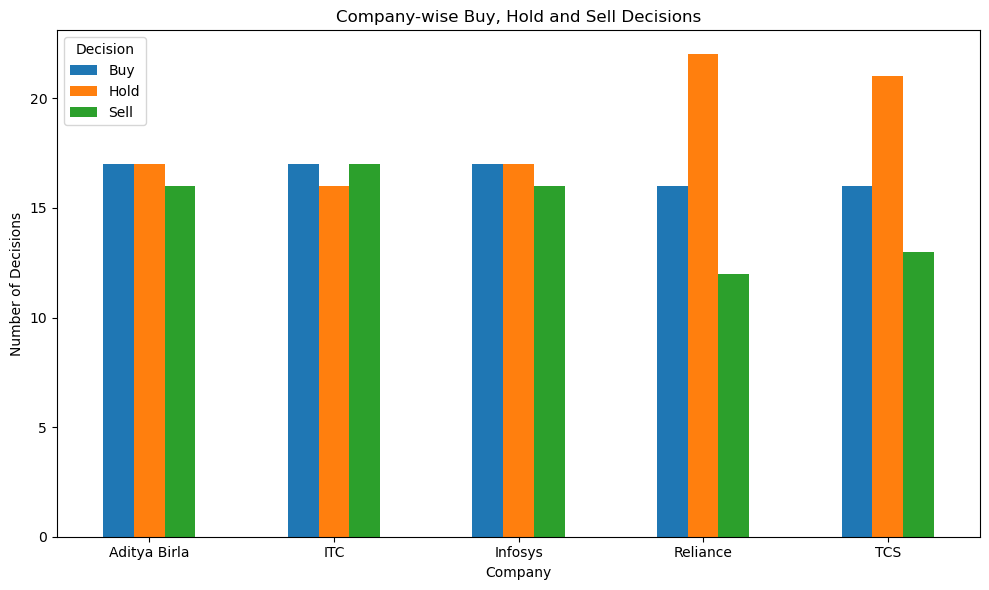

In [11]:
company_decision.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Company-wise Buy, Hold and Sell Decisions")
plt.xlabel("Company")
plt.ylabel("Number of Decisions")
plt.xticks(rotation=0)
plt.legend(title="Decision")
plt.tight_layout()
plt.show()

In [12]:
company_trend = pd.crosstab(
    bda_data["Company"],
    bda_data["Trend"]
)

company_trend

Trend,Down,Stable,Up
Company,,,
Aditya Birla,16,17,17
ITC,17,16,17
Infosys,16,17,17
Reliance,16,17,17
TCS,17,16,17


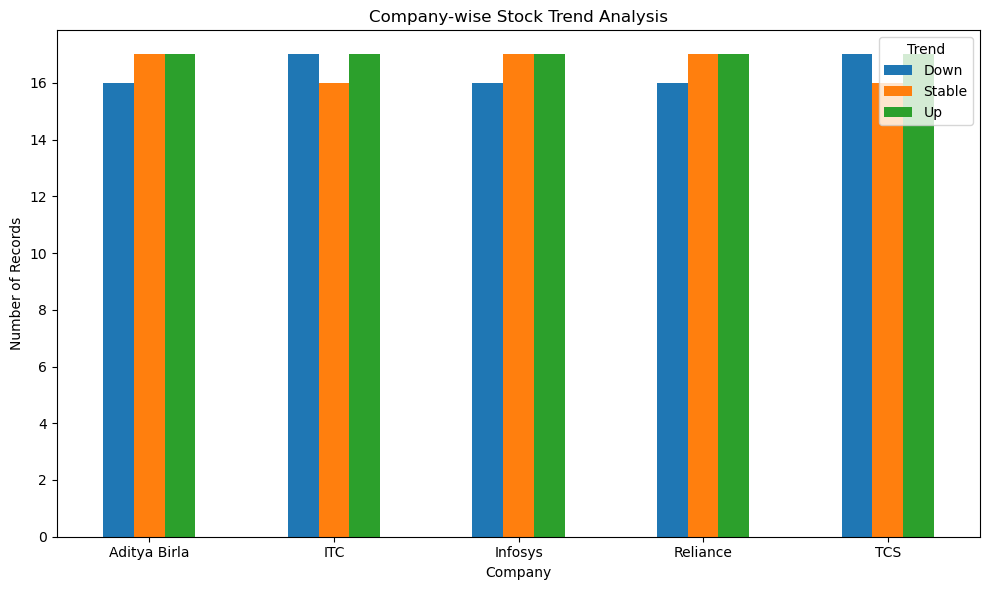

In [13]:
company_trend.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Company-wise Stock Trend Analysis")
plt.xlabel("Company")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.legend(title="Trend")
plt.tight_layout()
plt.show()

In [14]:
company_rsi = pd.crosstab(
    bda_data["Company"],
    bda_data["RSI"]
)

company_rsi

RSI,High,Low,Medium
Company,,,
Aditya Birla,16,10,24
ITC,13,12,25
Infosys,16,10,24
Reliance,13,14,23
TCS,16,13,21


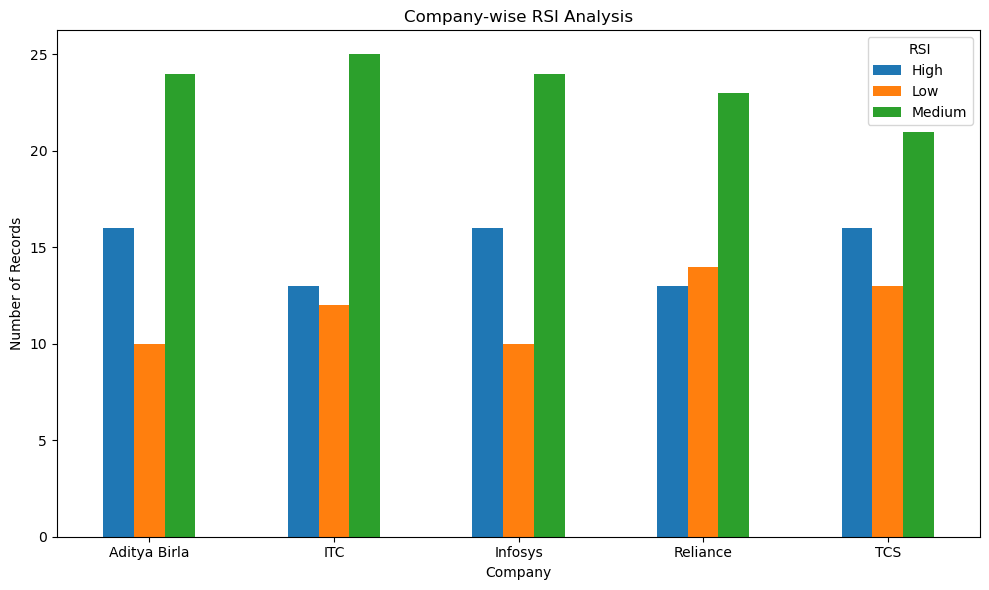

In [15]:
company_rsi.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Company-wise RSI Analysis")
plt.xlabel("Company")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.legend(title="RSI")
plt.tight_layout()
plt.show()

In [16]:
company_volume = pd.crosstab(
    bda_data["Company"],
    bda_data["Volume"]
)

company_volume

Volume,High,Low,Medium
Company,,,
Aditya Birla,26,0,24
ITC,15,15,20
Infosys,26,0,24
Reliance,17,14,19
TCS,19,14,17


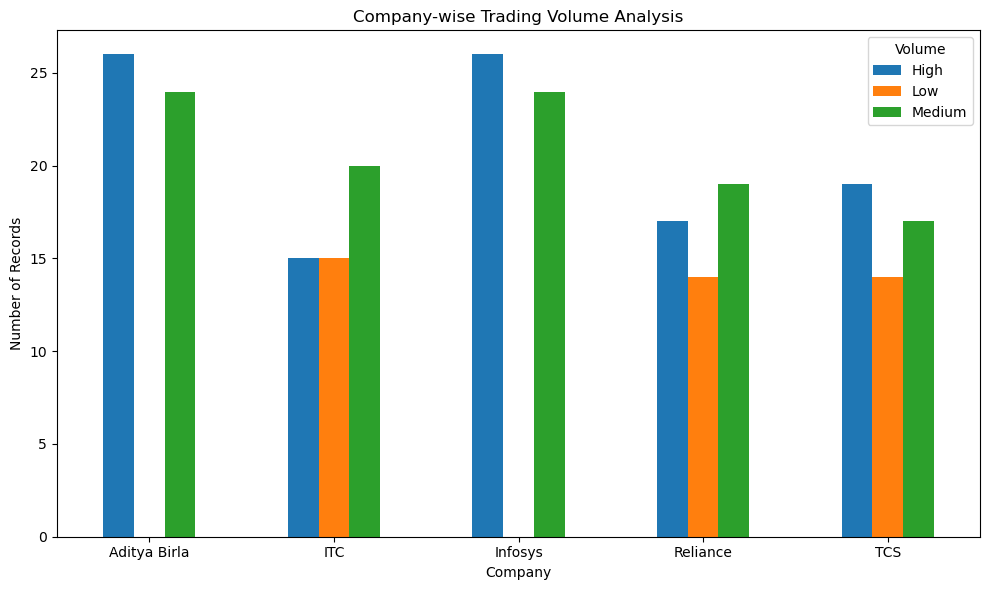

In [17]:
company_volume.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Company-wise Trading Volume Analysis")
plt.xlabel("Company")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.legend(title="Volume")
plt.tight_layout()
plt.show()

In [18]:
company_news = pd.crosstab(
    bda_data["Company"],
    bda_data["News"]
)

company_news

News,Negative,Positive
Company,,
Aditya Birla,16,34
ITC,17,33
Infosys,16,34
Reliance,17,33
TCS,19,31


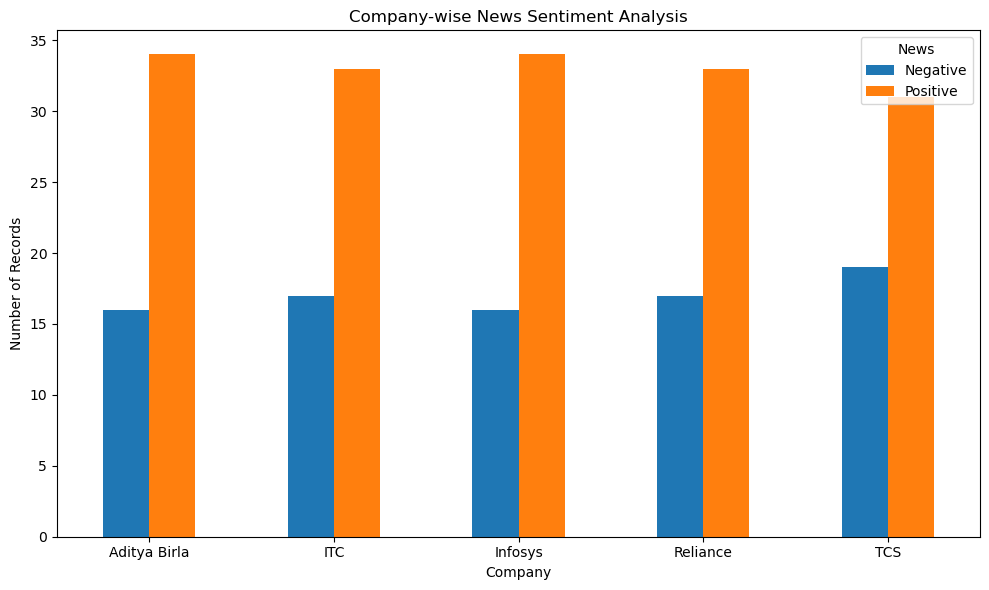

In [19]:
company_news.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Company-wise News Sentiment Analysis")
plt.xlabel("Company")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.legend(title="News")
plt.tight_layout()
plt.show()

In [20]:
trend_decision = pd.crosstab(
    bda_data["Trend"],
    bda_data["Decision"]
)

trend_decision

Decision,Buy,Hold,Sell
Trend,,,
Down,3,5,74
Stable,2,81,0
Up,78,7,0


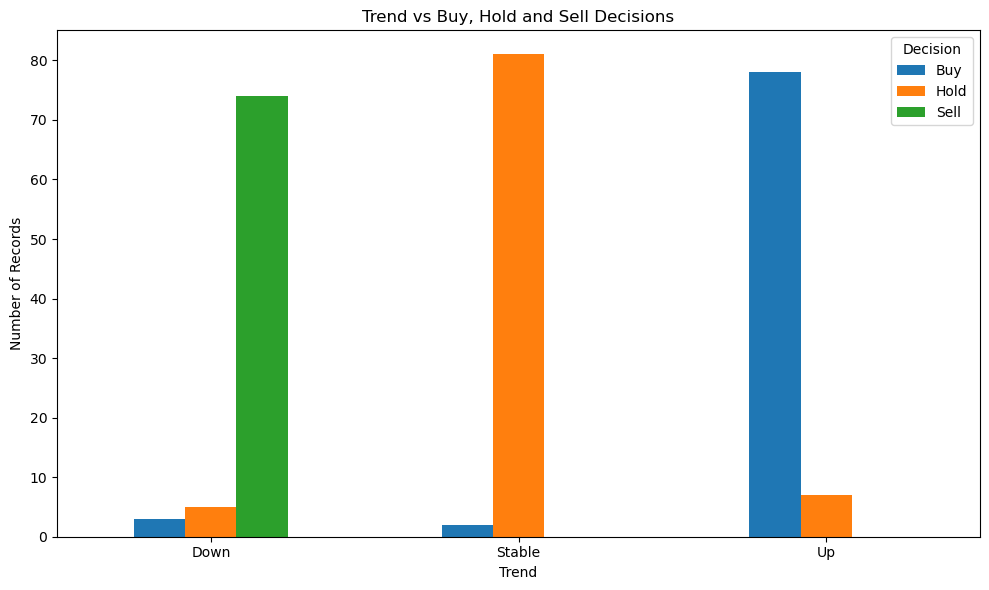

In [21]:
trend_decision.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Trend vs Buy, Hold and Sell Decisions")
plt.xlabel("Trend")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.legend(title="Decision")
plt.tight_layout()
plt.show()

In [22]:
rsi_decision = pd.crosstab(
    bda_data["RSI"],
    bda_data["Decision"]
)

rsi_decision

Decision,Buy,Hold,Sell
RSI,,,
High,12,15,47
Low,36,14,9
Medium,35,64,18


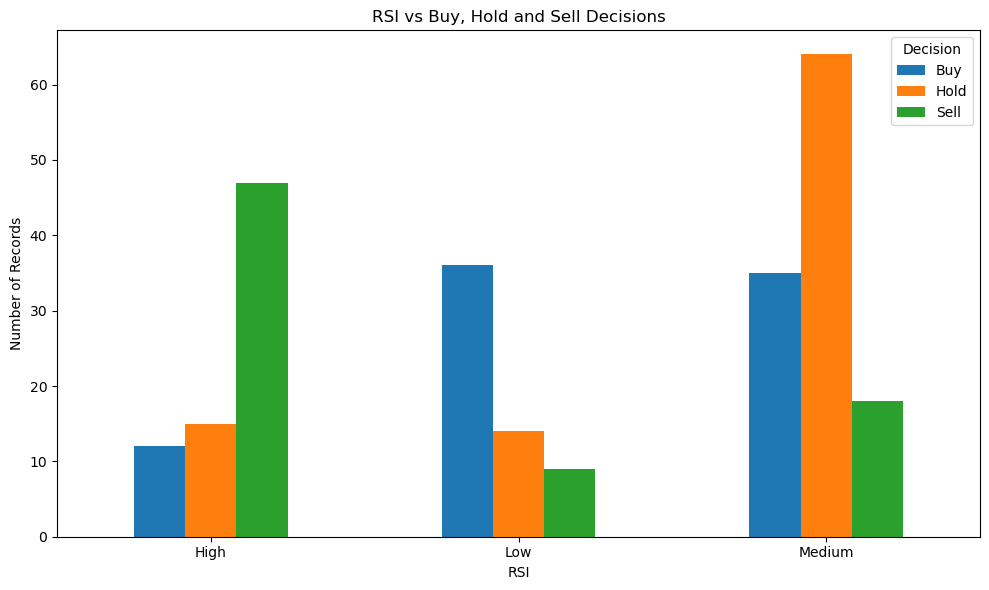

In [23]:
rsi_decision.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("RSI vs Buy, Hold and Sell Decisions")
plt.xlabel("RSI")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.legend(title="Decision")
plt.tight_layout()
plt.show()

In [24]:
volume_decision = pd.crosstab(
    bda_data["Volume"],
    bda_data["Decision"]
)

volume_decisionb

Decision,Buy,Hold,Sell
Volume,,,
High,38,33,32
Low,11,17,15
Medium,34,43,27


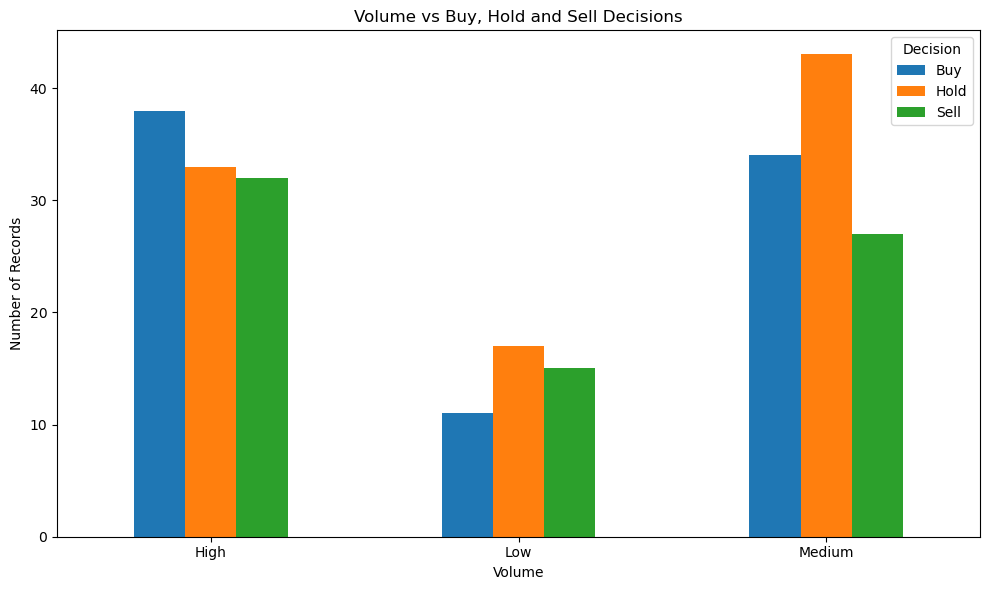

In [25]:
volume_decision.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Volume vs Buy, Hold and Sell Decisions")
plt.xlabel("Volume")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.legend(title="Decision")
plt.tight_layout()
plt.show()

In [26]:
news_decision = pd.crosstab(
    bda_data["News"],
    bda_data["Decision"]
)

news_decision

Decision,Buy,Hold,Sell
News,,,
Negative,0,11,74
Positive,83,82,0


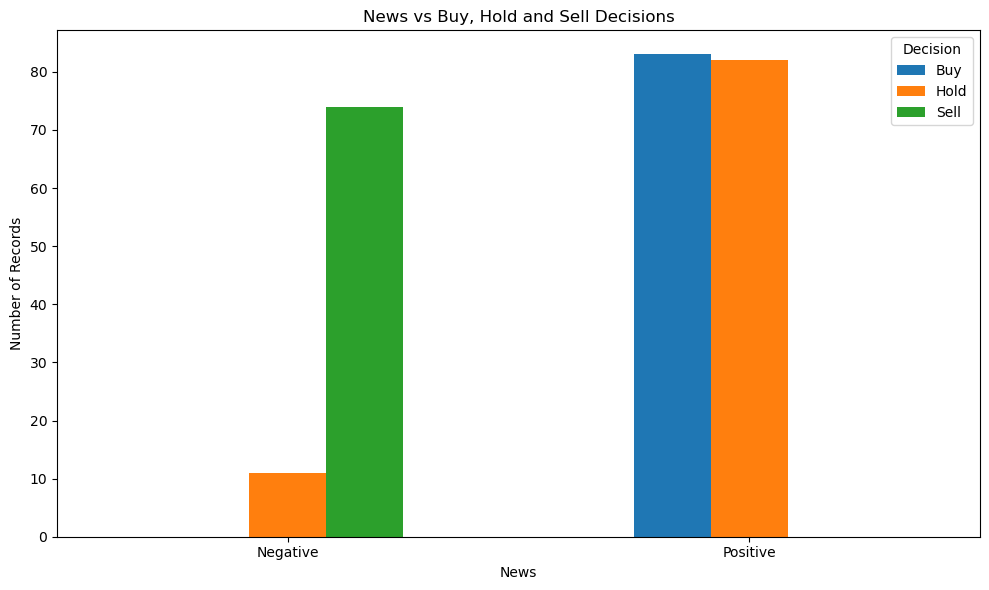

In [27]:
news_decision.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("News vs Buy, Hold and Sell Decisions")
plt.xlabel("News")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.legend(title="Decision")
plt.tight_layout()
plt.show()

In [28]:
decision_summary = bda_data["Decision"].value_counts()

decision_summary

Decision
Hold    93
Buy     83
Sell    74
Name: count, dtype: int64

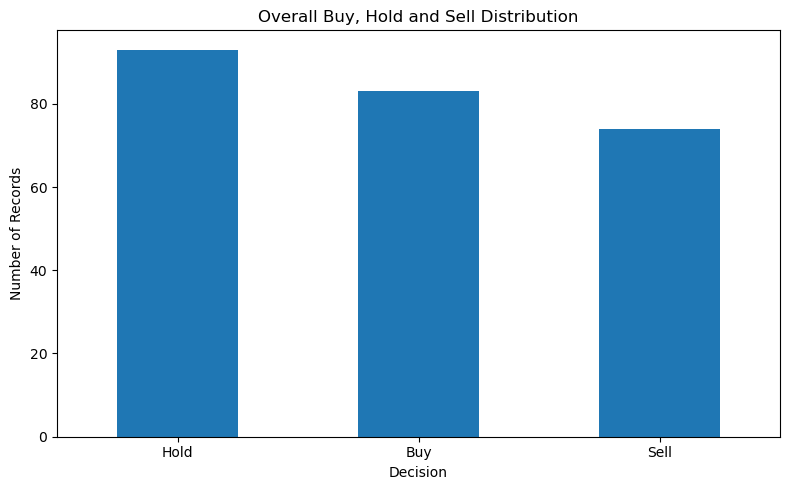

In [29]:
decision_summary.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Overall Buy, Hold and Sell Distribution")
plt.xlabel("Decision")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
summary = pd.DataFrame({
    "Analysis": [
        "Trend vs Decision",
        "RSI vs Decision",
        "News vs Decision",
        "Volume vs Decision",
        "Company vs Decision"
    ],
    "Key Finding": [
        "Up → Buy, Stable → Hold, Down → Sell",
        "Low RSI → Buy, Medium RSI → Hold, High RSI → Sell",
        "Positive News → Buy/Hold, Negative News → Sell",
        "Moderate relationship with decision",
        "Decision patterns vary across companies"
    ]
})

summary

,Analysis,Key Finding
0,Trend vs Decision,"Up → Buy, Stable → Hold, Down → Sell"
1,RSI vs Decision,"Low RSI → Buy, Medium RSI → Hold, High RSI → Sell"
2,News vs Decision,"Positive News → Buy/Hold, Negative News → Sell"
3,Volume vs Decision,Moderate relationship with decision
4,Company vs Decision,Decision patterns vary across companies


In [31]:
summary.reset_index(drop=True)

,Analysis,Key Finding
0,Trend vs Decision,"Up → Buy, Stable → Hold, Down → Sell"
1,RSI vs Decision,"Low RSI → Buy, Medium RSI → Hold, High RSI → Sell"
2,News vs Decision,"Positive News → Buy/Hold, Negative News → Sell"
3,Volume vs Decision,Moderate relationship with decision
4,Company vs Decision,Decision patterns vary across companies


In [32]:
summary.style.hide(axis="index")

Analysis,Key Finding
Trend vs Decision,"Up → Buy, Stable → Hold, Down → Sell"
RSI vs Decision,"Low RSI → Buy, Medium RSI → Hold, High RSI → Sell"
News vs Decision,"Positive News → Buy/Hold, Negative News → Sell"
Volume vs Decision,Moderate relationship with decision
Company vs Decision,Decision patterns vary across companies


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [34]:
ml_data = bda_data.copy()

label_encoders = {}

for column in ["Trend", "RSI", "Volume", "News", "Decision"]:
    le = LabelEncoder()
    ml_data[column] = le.fit_transform(ml_data[column])
    label_encoders[column] = le

ml_data.head()

,Day,Trend,RSI,Volume,News,Decision,Company
0,D1,2,0,0,1,0,TCS
1,D2,2,0,1,0,1,TCS
2,D3,0,1,0,1,0,TCS
3,D4,0,0,0,0,2,TCS
4,D5,1,2,2,1,1,TCS


In [35]:
X = ml_data[["Trend", "RSI", "Volume", "News"]]
y = ml_data["Decision"]

print("Features:", X.columns.tolist())
print("Target:", y.name)
print("Total Records:", len(X))

Features: ['Trend', 'RSI', 'Volume', 'News']
Target: Decision
Total Records: 250


In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Records:", len(X_train))
print("Testing Records:", len(X_test))

Training Records: 200
Testing Records: 50


In [37]:
model = DecisionTreeClassifier(
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [38]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print("Predicted values:", y_pred)

Predictions completed!
Predicted values: [0 2 0 2 0 2 1 0 1 0 1 1 0 2 0 2 0 1 2 2 1 0 2 1 0 2 1 2 1 1 0 0 2 0 1 2 1
 2 1 2 1 0 0 2 1 0 1 0 1 1]


In [39]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 100.0 %


In [40]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoders["Decision"].classes_
    )
)

Classification Report:
              precision    recall  f1-score   support

         Buy       1.00      1.00      1.00        17
        Hold       1.00      1.00      1.00        18
        Sell       1.00      1.00      1.00        15

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [41]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

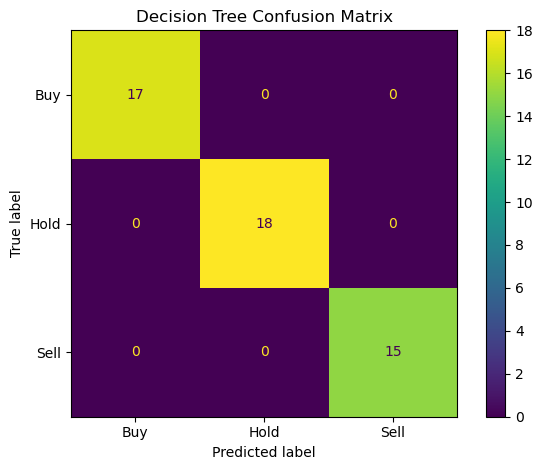

In [42]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoders["Decision"].classes_
)

disp.plot()
plt.title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()

In [43]:
comparison = pd.DataFrame({
    "Actual Decision": label_encoders["Decision"].inverse_transform(y_test),
    "Predicted Decision": label_encoders["Decision"].inverse_transform(y_pred)
})

comparison.head(10)

,Actual Decision,Predicted Decision
0,Buy,Buy
1,Sell,Sell
2,Buy,Buy
3,Sell,Sell
4,Buy,Buy
5,Sell,Sell
6,Hold,Hold
7,Buy,Buy
8,Hold,Hold
9,Buy,Buy


In [44]:
comparison.reset_index(drop=True).head(10)

,Actual Decision,Predicted Decision
0,Buy,Buy
1,Sell,Sell
2,Buy,Buy
3,Sell,Sell
4,Buy,Buy
5,Sell,Sell
6,Hold,Hold
7,Buy,Buy
8,Hold,Hold
9,Buy,Buy


In [45]:
comparison = pd.DataFrame({
    "Actual Decision": label_encoders["Decision"].inverse_transform(y_test),
    "Predicted Decision": label_encoders["Decision"].inverse_transform(y_pred)
}).reset_index(drop=True)

comparison.index = comparison.index + 1

comparison.head(10)

,Actual Decision,Predicted Decision
1,Buy,Buy
2,Sell,Sell
3,Buy,Buy
4,Sell,Sell
5,Buy,Buy
6,Sell,Sell
7,Hold,Hold
8,Buy,Buy
9,Hold,Hold
10,Buy,Buy
